In [1]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/Users/mrenke/data/ds-stressrisk'
plot_folder_path = '/Users/mrenke/Desktop/StressRisk/figures/plots/paper'

sns.set_context('talk')
sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')


In [2]:
from stress_risk.behavior.utils import get_data
df = get_data()
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)


WARNING (aesara.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
/Users/mrenke/mambaforge/envs/behav_fit2_clone/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit2_clone/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Methdos

## RNP & psychometric curve illustration

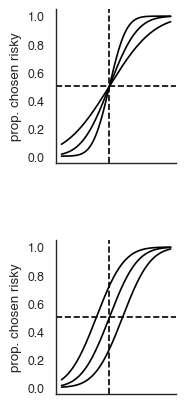

In [254]:
import scipy.stats as ss

sns.set_theme('paper', 'white', font='helvetica', font_scale=1, palette='tab10')

x = np.linspace(-.5, 2, 500)
mu_rn = np.log(1/0.55)
fig, axs = plt.subplots(2, 1, figsize=(2, 5))

for sd in [.3, .5, .8]:
    d = ss.norm(mu_rn, sd)
    axs[0].plot(x, d.cdf(x), color='k')
axs[0].axvline(mu_rn, color='k', linestyle='--')
axs[0].axhline(0.5, color='k', linestyle='--')
axs[0].set(xticks=[], ylabel='prop. chosen risky')

for mu in [ mu_rn - 0.3, mu_rn, mu_rn + 0.3]:
    d = ss.norm(mu, .5)
    axs[1].plot(x, d.cdf(x), color='k')
axs[1].axvline(mu_rn, color='k', linestyle='--')
axs[1].axhline(0.5, color='k', linestyle='--')
axs[1].set(xticks=[], ylabel='prop. chosen risky')

fig.subplots_adjust(hspace = 0.5, left=0.3) # adjust vertical space between axes
#fig.suptitle('prop. chosen risky', y=0.5, x=0,rotation='vertical', va='center')

sns.despine()
plt.savefig(op.join(plot_folder_path, f'probit-model_illustration_01.pdf'), bbox_inches='tight')


In [2]:
probit_params = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/probit-1_pposterior_params.csv')
probit_params.set_index(['param','subject','session','group','risky_first','n_safe'], inplace=True)
probit_params.drop('Unnamed: 0', axis=1, inplace=True)
probit_params.rename(columns={'chose_risky_mean':'chose_risky_mean.0'}, inplace=True)
color = 'grey'
probit_params.head()

# rename columns to multiindex (draw, chose_risky_mean)
split_columns = probit_params.columns.str.split('.', expand=True)
probit_params.columns = pd.MultiIndex.from_tuples(split_columns)
probit_params.head()

chose_risky_mean            \
                                                              0         1   
param subject session group risky_first n_safe                              
rnp   1       1       0.0   True        10.0           0.501135  0.524781   
                                        7.0            0.501135  0.524781   
                                        28.0           0.501135  0.524781   
                                        14.0           0.501135  0.524781   
                                        20.0           0.501135  0.524781   

                                                                           \
                                                       2      3         4   
param subject session group risky_first n_safe                              
rnp   1       1       0.0   True        10.0    0.509993  0.549  0.555853   
                                        7.0     0.509993  0.549  0.555853   
                                        28.0    0.509993  0.549  0.555853   
                                        14.0    0.509993  0.549  0.555853   
                                        20.0    0.509993  0.549  0.555853   

                                                                              \
                                                       5         6         7   
param subject session group risky_first n_safe                                 
rnp   1       1       0.0   True        10.0    0.535292  0.502861  0.494759   
                                        7.0     0.535292  0.502861  0.494759   
                                        28.0    0.535292  0.502861  0.494759   
                                        14.0    0.535292  0.502861  0.494759   
                                        20.0    0.535292  0.502861  0.494759   

                                                                    ...  \
                                                       8         9  ...   
param subject session group risky_first n_safe                      ...   
rnp   1       1       0.0   True        10.0    0.504208  0.575527  ...   
                                        7.0     0.504208  0.575527  ...   
                                        28.0    0.504208  0.575527  ...   
                                        14.0    0.504208  0.575527  ...   
                                        20.0    0.504208  0.575527  ...   

                                                                              \
                                                    3990      3991      3992   
param subject session group risky_first n_safe                                 
rnp   1       1       0.0   True        10.0    0.464776  0.491672  0.510233   
                                        7.0     0.464776  0.491672  0.510233   
                                        28.0    0.464776  0.491672  0.510233   
                                        14.0    0.464776  0.491672  0.510233   
                                        20.0    0.464776  0.491672  0.510233   

                                                                              \
                                                    3993      3994      3995   
param subject session group risky_first n_safe                                 
rnp   1       1       0.0   True        10.0    0.475432  0.499024  0.453383   
                                        7.0     0.475432  0.499024  0.453383   
                                        28.0    0.475432  0.499024  0.453383   
                                        14.0    0.475432  0.499024  0.453383   
                                        20.0    0.475432  0.499024  0.453383   

                                                                              \
                                                    3996      3997      3998   
param subject session group risky_first n_safe                                 
rnp   1       1       0.0   True        10.0    0

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_25551/1807573931.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dd.drop('intercept', axis=0, inplace=True)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_25551/1807573931.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='value of posterior estimate',ylim= [-.2,.5],xlabel=None,xticklabels=['slope','RNP']) # xlabel=None,,xticklabels=['


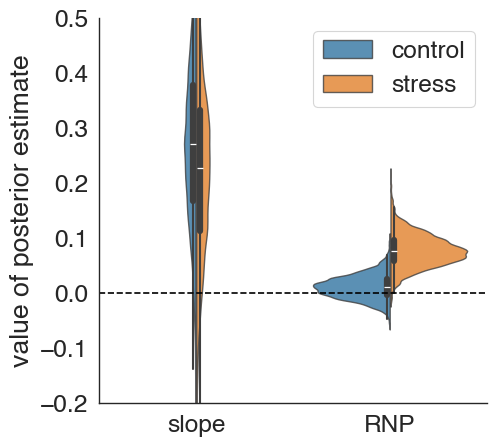

In [397]:
dd = probit_params.xs(2,0,'session') - probit_params.xs(1,0,'session')
dd.drop('intercept', axis=0, inplace=True)
dd = dd.stack().rename(mapper={'chose_risky_mean':'y'},axis=1).reset_index()
dd['group'] = dd['group'].replace({0: 'control', 1: 'stress'})

# reorder df so that slope is first
dd['index_column'] = pd.Categorical(dd['param'], categories=['gamma', 'rnp'], ordered=True)
dd = dd.sort_values(['index_column', 'group']) # preserve order of group

plt.figure(figsize=(5, 5)) 
ax = sns.violinplot(dd,y='y', x='param',hue='group',split=True,legend=True,gap=.01,alpha=.8) #
ax.axhline(0, c='k', ls='--')
sns.despine()
ax.set(ylabel='value of posterior estimate',ylim= [-.2,.5],xlabel=None,xticklabels=['slope','RNP']) # xlabel=None,,xticklabels=['
ax.legend(title='')
#plt.gcf().set_size_inches(6, 3)
#plt.savefig(op.join(plot_folder_path, f'probit-model_diffinsessions_violin.pdf'), bbox_inches='tight')


In [6]:
dd = probit_params.xs(2,0,'session') - probit_params.xs(1,0,'session')
dd.drop('intercept', axis=0, inplace=True)
dd = dd.stack().rename(mapper={'chose_risky_mean':'y'},axis=1).reset_index('group')
dd['group'] = dd['group'].replace({0: 'control', 1: 'stress'})
dd.head()

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_15017/1355692183.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dd.drop('intercept', axis=0, inplace=True)


group         y
param subject risky_first n_safe                        
rnp   1       True        10.0   0     control  0.041900
                                 1     control  0.031974
                                 10    control -0.000109
                                 100   control  0.004876
                                 1000  control  0.025729

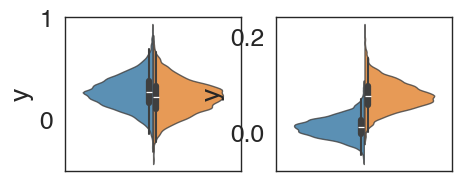

In [12]:

params = ['gamma', 'rnp']

fig, axs = plt.subplots(1,2, figsize=(5, 2))

for ax, param in zip(axs, params):
    #sns.barplot(ax=ax, data=df_comb.reset_index(), x='group', y=column, alpha=0.5)
    sns.violinplot(dd.xs(param,0,'param').reset_index(),y='y', hue='group',split=True,legend=False,gap=.01,alpha=.8, ax=ax) # x='param',


In [371]:

def plot_diffindiff(d, param_name, color):
    dd_0= np.asarray(d[(d['session']==2) & (d['group']==0)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==0)]['y'])
    dd_1= np.asarray(d[(d['session']==2) & (d['group']==1)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==1)]['y'])
    dd = dd_1 - dd_0
    #fac = sns.histplot(dd, bins=50, color = color)
    fac = sns.kdeplot(dd, color = color, fill=True)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel(f'{param_name}') #\n [(group1(ses2-ses1) - group0(ses2-ses1)]') : diff in diff
    plt.title(f'p = {np.round(np.mean(dd>0),3)}')
    sns.despine()
    fac.set(ylabel=None, yticks=[]) #xlabel=None, 
    plt.title(f'p = {np.round(np.mean(dd<0),3)}')
    sns.despine()
    return fac
    

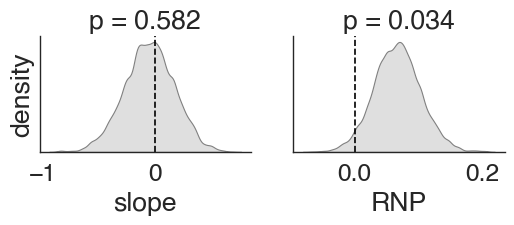

In [393]:

sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')

plt.subplot(121)
d = probit_params.xs('gamma',0,'param')
d = d.stack().rename(mapper={'chose_risky_mean':'y'},axis=1).reset_index()
fac = plot_diffindiff(d, 'slope', color)
ax = plt.gca()
ax.set_ylabel('density')

plt.subplot(122)
d = probit_params.xs('rnp',0,'param')
d = d.stack().rename(mapper={'chose_risky_mean':'y'},axis=1).reset_index()
fac = plot_diffindiff(d, 'RNP', color)

plt.gcf().set_size_inches(6, 1.5)
plt.savefig(op.join(plot_folder_path, f'probit-model_diffindiff.pdf'), bbox_inches='tight')


## NLC model illustration

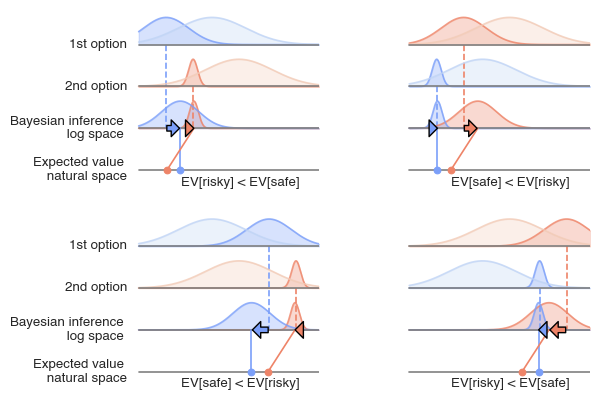

In [5]:

from utils import plot_bayesian_inference, annotat_bayesian_inference
import seaborn as sns 
import matplotlib.pyplot as plt

sns.set_theme('paper', 'white', font='helvetica', font_scale=1, palette='tab10')

plt.subplot(221)
plot_bayesian_inference(risky_first = False,base = 5)
annotat_bayesian_inference()
plt.subplot(222)
plot_bayesian_inference(risky_first = True,base = 5)
plt.subplot(223)
plot_bayesian_inference(risky_first = False,base = 49)
annotat_bayesian_inference()
plt.subplot(224)
plot_bayesian_inference(risky_first = True,base = 49)

plt.savefig(op.join(plot_folder_path, f'NLC-model_illustration_01.pdf'), bbox_inches='tight')


# Results

### probit model

In [ ]:
params = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/probit-1_pposterior_params.csv')
#params.columns = params.columns.droplevel(params.columns[0])
params = params.drop('Unnamed: 0',axis=1)
params = params.set_index(['param','subject','session','group','risky_first','n_safe'])

params.head()

## just created plots in fi2_rnp 

### NLC model

In [2]:
import arviz as az
from bauer.utils.math import softplus_np

idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-1_trace.netcdf'))

def get_posterior(idata,param,regressor):
    df = idata.posterior[param].to_dataframe()
    df.index = df.index.set_names(['chain','draw','subject','regressor'])
    df = df.xs(regressor, 0,'regressor')
    df['regressor'] = regressor
    return df

def get_post_diffindiff(idata,param):
    df_control_dif = get_posterior(idata,param,'session')
    df_stress_dif = get_posterior(idata,param,'session') + get_posterior(idata,param,'session:group')
    df_c = pd.concat((df_control_dif, df_stress_dif), axis=0)
    df_c = df_c.set_index('regressor', append=True)
    return df_c
    

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


#### baseline estimates

In [ ]:
# intercept bzw. baseline estimates
params = ['safe_prior_mu','risky_prior_mu','safe_prior_std','risky_prior_std','n1_evidence_sd','n2_evidence_sd']

dd = pd.DataFrame()
for param in params:
    df_control = get_posterior(idata,param,'Intercept')
    df_stress = get_posterior(idata,param,'Intercept') + get_posterior(idata,param,'group')
    #df = pd.concat((df_control, df_stress), axis=1)
    df = np.mean(pd.concat((df_control, df_stress), axis=1), axis=1).to_frame('value')
    if param.endswith('d'):
        df['value'] = softplus_np(df['value'])
    df['regressor'] = param.split('_', 1)[1]
    df['option'] = param.split('_', 1)[0]
    df = df.set_index(['option','regressor'], append=True)
    dd = pd.concat((dd, df), axis=0)



/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_25551/270178213.py:17: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.kdeplot(data=d, x='value',hue='option', fill=True, ax=ax,palette=palette) # , color='grey'


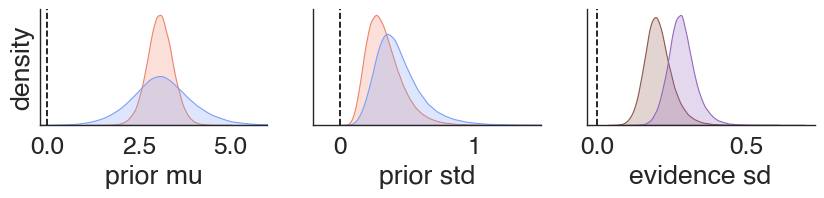

In [200]:
sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')

palette_ev = sns.color_palette()[4:]
palette = sns.color_palette('coolwarm', 4)
palette_prior = [palette[ix] for ix in [0, 3]]

fig, axs = plt.subplots(1,3, figsize=(10,1.5)) # 5*len(dd.columns)

regressors = dd.index.get_level_values('regressor').unique()

for ax, regressor in  zip(axs,regressors):
    d = dd.xs(regressor, 0,'regressor')
    if regressor == 'evidence_sd':
        d.index = d.index.set_levels(['first', 'second'], level='option') 
        
    palette = palette_prior if 'prior' in regressor else palette_ev
    sns.kdeplot(data=d, x='value',hue='option', fill=True, ax=ax,palette=palette) # , color='grey'

    if regressor == 'prior_std':
            ax.set(xlim = [-.2, 1.5]) 
    elif regressor == 'prior_mu':
            ax.set(xlim =[-.2, 6]) 
     
    ax.set_xlabel(regressor)
    ax.axvline(0, c='k', ls='--')
    ax.set(ylabel=None, yticks=[]) # xlabel=None, 
    ax.get_legend().remove()    
    ax.set_xlabel(regressor.replace('_',' '))

sns.despine()
axs[0].set_ylabel('density')

plt.savefig(op.join(plot_folder_path, f'NLC-post_baesline.pdf'), bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

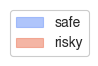

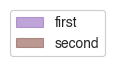

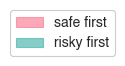

In [271]:
import matplotlib.patches as patches

# Create a new figure for the legend
legend_fig = plt.figure()
palette_ppc = sns.color_palette("husl", 2)

# Create a custom legend
for colors, labels in zip([palette_prior, palette_ev,palette_ppc],[["safe", "risky"], ["first", "second"], ["safe first","risky first"]]) : #["#1f77b4", "#ff7f0e"] # replace with your colors
    legend_fig = plt.figure()

    patches_list = [patches.Patch(color=colors[i], label=labels[i], alpha=0.6) for i in range(len(labels))]
    # Set the legend
    legend = legend_fig.legend(handles=patches_list, bbox_to_anchor=(0.5, 0.5), loc='center', ncol=1, 
                    facecolor="white", framealpha=1, fontsize=10)
    # Remove the plot frame
    legend_fig.canvas.draw()
    legend_fig.gca().set_axis_off()

    # Adjust the legend position and size to fill the whole figure
    bbox = legend.get_window_extent().transformed(legend_fig.dpi_scale_trans.inverted())
    legend_fig.set_size_inches(bbox.width, bbox.height)
    plt.savefig(op.join(plot_folder_path, f'NLC_legend_{labels[0]}-{labels[1]}.pdf'), bbox_inches='tight')
    plt.show()

### diff between sessions

In [3]:
df_sp = get_post_diffindiff(idata,'safe_prior_mu')
df_rp = get_post_diffindiff(idata,'risky_prior_mu')
df_1e = get_post_diffindiff(idata,'n1_evidence_sd')
df_2e = get_post_diffindiff(idata,'n2_evidence_sd')

dd = pd.concat([df_rp,df_sp,df_1e,df_2e], axis=1)
dd = dd.stack().to_frame('value')
dd.index = dd.index.set_names(['chain','draw','subject','regressor','param'])
dd.index = dd.index.set_levels(['control', 'stress'], level='regressor')

dd.head()

value
chain draw subject regressor param                   
0     0    1       control   risky_prior_mu  0.093866
                             safe_prior_mu  -0.118882
                             n1_evidence_sd -0.039612
                             n2_evidence_sd -0.205532
           2       control   risky_prior_mu -0.066194

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_52913/2615101760.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylabel='value of posterior estimate',ylim= [-2,2],xlabel=None,xticklabels=['risky prior','safe prior','evidence sd 1','evidence sd 2']) # xlabel=None,


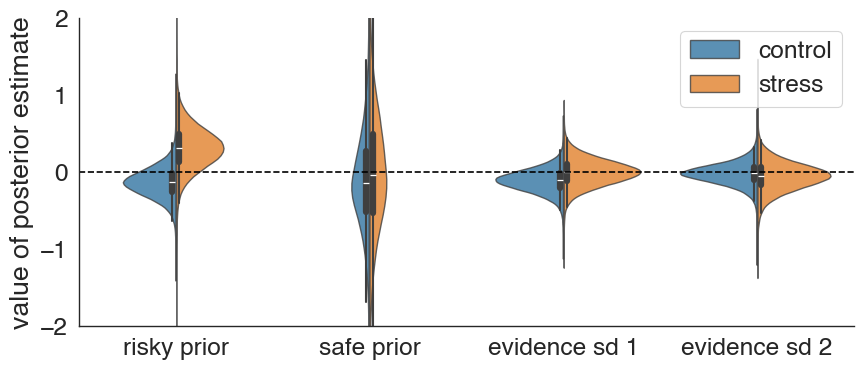

In [4]:
split=True
sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')

plt.figure(figsize=(10, 4)) 
ax = sns.violinplot(dd,y='value', x='param',hue='regressor',split=split,legend=True,gap=.01,alpha=.8) #
ax.axhline(0, c='k', ls='--')
sns.despine()
ax.set(ylabel='value of posterior estimate',ylim= [-2,2],xlabel=None,xticklabels=['risky prior','safe prior','evidence sd 1','evidence sd 2']) # xlabel=None,
ax.legend(title='')

plt.savefig(op.join(plot_folder_path, f'NLC-post_stres-control_violin_spli-{split}.pdf'), bbox_inches='tight')

### diff in diff

In [5]:
df_sp = get_posterior(idata,'safe_prior_mu','session:group').drop('regressor', axis=1)
df_rp = get_posterior(idata,'risky_prior_mu','session:group').drop('regressor', axis=1)
df_1e = get_posterior(idata,'n1_evidence_sd','session:group').drop('regressor', axis=1)
df_2e = get_posterior(idata,'n2_evidence_sd','session:group').drop('regressor', axis=1)

dd = pd.concat([df_rp,df_sp, df_1e,df_2e], axis=1)

In [6]:
dd.head()

risky_prior_mu  safe_prior_mu  n1_evidence_sd  \
chain draw subject                                                  
0     0    1              1.290285      -0.136764        0.037867   
           2              0.150087      -0.093432        0.091112   
           3              0.852714      -0.102028        0.035822   
           4              0.484594      -0.102600        0.056644   
           5              0.552856      -0.075863       -0.050828   

                    n2_evidence_sd  
chain draw subject                  
0     0    1             -0.004874  
           2             -0.172278  
           3             -0.257373  
           4             -0.174414  
           5              0.145154

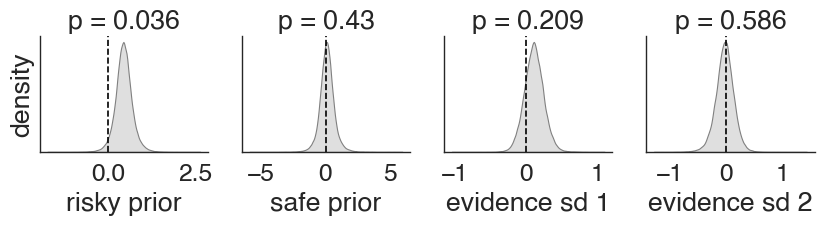

In [7]:
fig, axs = plt.subplots(1,len(dd.columns), figsize=(10,1.5)) # 5*len(dd.columns)

col_names = ['risky prior','safe prior','evidence sd 1','evidence sd 2']

for ax, column, col_name in zip(axs, dd.columns,col_names):
    sns.kdeplot(data=dd, x=column, fill=True, ax=ax, color='grey')
    
    ax.set_title(f'p = {np.round(np.mean(dd[column]<0),3)}')
    ax.set_xlabel(col_name)
    ax.axvline(0, c='k', ls='--')
    ax.set(ylabel=None, yticks=[]) # xlabel=None, 

axs[0].set_ylabel('density')
sns.despine()
#plt.tight_layout()
plt.savefig(op.join(plot_folder_path, f'NLC-post_diffindiff_dist.pdf'), bbox_inches='tight')

## Decoding

In [3]:
# E_diff
Es_within = pd.read_csv(op.join(bids_folder, 'interim_sum_data', 'within_ses_decodedE.csv'))
Es_across = pd.read_csv(op.join(bids_folder, 'interim_sum_data','across_ses_decodedE.csv'))

Es_within = Es_within.set_index(['subject', 'trial_nr', 'session']).rename(mapper={'E':'E_w', 'sd':'sd_w'}, axis=1).xs(2,0,'session')
Es_across = Es_across.set_index(['subject', 'trial_nr']).rename(mapper={'E':'E_a', 'sd':'sd_a'}, axis=1)

from stress_risk.utils.data import add_cond2df
Es = Es_within.join(Es_across).set_index('risky_first', append=True)
Es = add_cond2df(Es)
Es['E_dif'] = Es['E_a'] - Es['E_w']

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


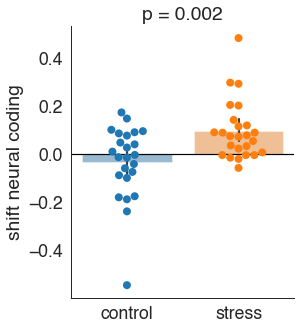

In [77]:
import pingouin
sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')

temp = Es.groupby(['subject']).mean()
temp['group_name'] = np.where(temp['group'] == 0, 'control', 'stress')

#sns.catplot(data=temp.reset_index(), x='group_name', y='E_dif',  kind='bar') #kind='bar',,errorbar=get_hdi

plt.figure(figsize=(4, 5)) 
sns.barplot(data=temp.reset_index(), x='group_name', y='E_dif', alpha=0.5)
sns.swarmplot(data=temp.reset_index(), x='group_name', y='E_dif', size=8)

plt.xlabel(None)
plt.ylabel('shift neural coding')
an = pingouin.anova(data=temp.reset_index(), dv='E_dif', between='group')
p_val = np.round(an['p-unc'][0],3)
plt.title(f'p = {p_val}')
plt.axhline(0, c='black')
sns.despine()
plt.savefig(op.join(plot_folder_path, 'shift-neural-coding_swarm-bar-plot_groups.pdf'), bbox_inches='tight')

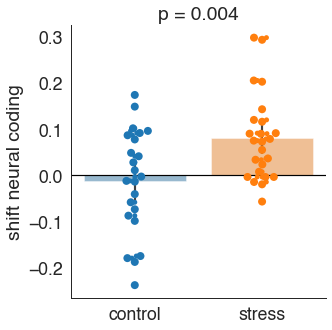

In [78]:
# outlier removed
max_val = temp['E_dif'].max()
min_val = temp['E_dif'].min()
filtered_temp = temp[(temp['E_dif'] != max_val) & (temp['E_dif'] != min_val)]

sns.catplot(data=filtered_temp.reset_index(), x='group_name', y='E_dif',  kind='swarm') #kind='bar',,errorbar=get_hdi

sns.barplot(data=filtered_temp.reset_index(), x='group_name', y='E_dif', alpha=0.5)
sns.swarmplot(data=filtered_temp.reset_index(), x='group_name', y='E_dif', size=8)

plt.xlabel(None)
plt.ylabel('shift neural coding')
an = pingouin.anova(data=filtered_temp.reset_index(), dv='E_dif', between='group')
p_val = np.round(an['p-unc'][0],3)
plt.title(f'p = {p_val}')
plt.axhline(0, c='black')

In [79]:
df_wdec = pd.read_csv(op.join(bids_folder, 'interim_sum_data','within-ses-decod_r-sds.csv'))
df_wdec = df_wdec.set_index(['group','subject','session'])

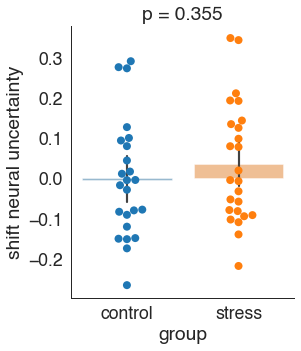

In [84]:
import pingouin
from matplotlib.ticker import FormatStrFormatter

y_var = 'r'
dd = df_wdec.xs(1,0,'session') - df_wdec.xs(2,0,'session')

plt.figure(figsize=(4, 5)) 
fac = sns.barplot(data=dd.reset_index(), x='group', y=y_var, alpha=0.5)
sns.swarmplot(ax=fac,data=dd.reset_index(), x='group', y=y_var,size=8)

plt.ylabel('shift neural uncertainty')
sns.despine()

an = pingouin.anova(data=dd.reset_index(), dv=y_var, between='group')
p_val = np.round(an['p-unc'][0],3)
plt.title(f'p = {p_val}')
plt.savefig(op.join(plot_folder_path, 'shift_decodability-r_catplot-groups.pdf'), bbox_inches='tight')

## AUC group difference

In [57]:
from stress_risk.analyse_results.utils import get_stress_level
df_stress_sr = pd.read_csv('/Users/mrenke/data/ds-stressrisk/addMeasures/selfRated_Stress.csv')
df_stress_sr_all = pd.read_csv('/Users/mrenke/data/ds-stressrisk/addMeasures/selfRated_Stress_allMeasures.csv')

stress_measure = 'mean_stress' #'auc_stress'
df_stress_sr = df_stress_sr_all.set_index(['subject','group'])[[stress_measure]]
#df_stress_sr.head()

In [58]:
df_stress_sr = df_stress_sr.rename(mapper={stress_measure:'self-rated_auc'}, axis=1)
df_auc = get_stress_level().rename(mapper={'AUC':'cortisol_auc'}, axis=1)

df_comb = df_auc.join(df_stress_sr.reset_index('group'))
df_comb['group'] = np.where( df_comb['group']== 0.0, 'control', 'stress')
df_comb = df_comb.set_index('group', append=True)
df_comb.head()

,,cortisol_auc,self-rated_auc
subject,group,,
1,control,2.060,6.981949
2,control,-0.505,2.843103
3,stress,3.530,7.110147
4,stress,1.055,7.074323
5,control,-0.635,2.557188


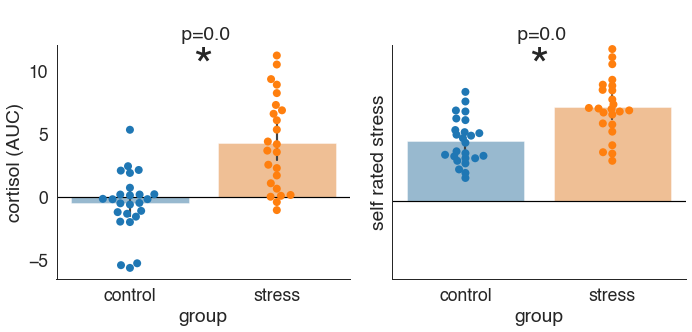

In [76]:
from scipy.stats import ttest_ind

col_names = ['cortisol_auc', 'self-rated_auc']

fig, axs = plt.subplots(1, 2, figsize=(10,5))

for ax, column in zip(axs, col_names):
    sns.barplot(ax=ax, data=df_comb.reset_index(), x='group', y=column, alpha=0.5)
    sns.swarmplot(ax=ax, data=df_comb.reset_index(), x='group', y=column, size=8)
    if column == 'self-rated_auc':
        ax.set_ylim([-5,10])
        ax.set_yticks([])
    ax.axhline(0, c='black')
    t_stat, p_val = ttest_ind(df_comb.xs('control',0,'group')[column], df_comb.xs('stress',0,'group')[column])
    ax.set_title(f'\n p={np.round(p_val,3)}') # {column} 
    if p_val < 0.05:
        ax.text(0.5, 0.8, '*', transform=ax.transAxes, ha='center', va='bottom',fontsize=50) 


axs[0].set_ylabel('cortisol (AUC)')
axs[1].set_ylabel('self rated stress')

plt.tight_layout()
sns.despine()
plt.savefig(op.join(plot_folder_path, 'stress_swarmplot.pdf'), bbox_inches='tight')

# Behav - Neural - corr.

### stress-effect: shift-prior with E-diff

In [405]:
# load in data frame from behavior/shifts_decode-priors.ipynb
df_comb_shifts = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/r-prior-shift_Ediff_AUC.csv')
#len(Es.index.unique('subject')) # sub 1 is missing

<Figure size 400x400 with 0 Axes>

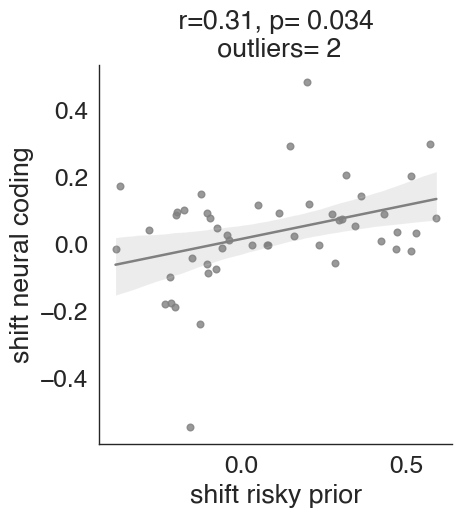

In [415]:
import pingouin
sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')

name_prior = 'risky_prior'
method = 'shepherd' # = robust, N-outliers = 2

temp = df_comb_shifts

plt.figure(figsize=(4, 4)) 
fac = sns.lmplot(data=temp.reset_index() , y = 'E_dif',x= f'{name_prior}_mu',line_kws={'color': 'grey'}, scatter_kws={'color': 'grey'}) #, hue='group'
cor = pingouin.corr(temp['E_dif'], temp[f'{name_prior}_mu'], method='shepherd')
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)
outliers = cor['outliers'][0]
fac.set(xlabel='shift risky prior',ylabel='shift neural coding', title = f' r={r_}, p= {p} \n outliers= {outliers}')
plt.savefig(op.join(plot_folder_path, 'shift-prior_E-diff_corr_robust.pdf'), bbox_inches='tight')

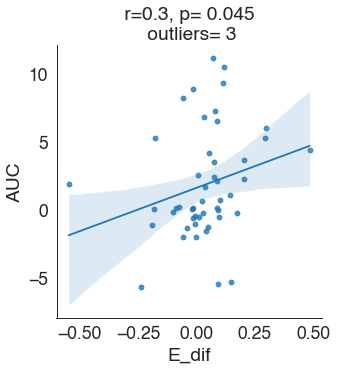

In [108]:

temp = df_comb_shifts

x_var = 'E_dif'# 'risky_prior_mu' #
fac = sns.lmplot(data=temp.reset_index() , x=x_var, y = 'AUC') 
cor = pingouin.corr(temp[x_var], temp[f'AUC'], method='shepherd')
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)
outliers = cor['outliers'][0]

fac.set(xlabel=x_var,ylabel='AUC', title = f' r={r_}, p= {p} \n outliers= {outliers}')
plt.savefig(op.join(plot_folder_path, f'shift-{x_var}_AUC_corr_robust.pdf'), bbox_inches='tight')


In [31]:
pingouin.corr(df_comb['E_dif'], df_comb[f'{name_prior}_mu'], method='shepherd')

,n,outliers,r,CI95%,p-val,power
shepherd,49,2,0.309551,"[0.02, 0.55]",0.034231,0.572408


### general: n2 evid. with r/neural uncertainty

In [38]:
n2s= pd.read_csv(op.join('/Users/mrenke/data/ds-stressrisk/interim_sum_data', 'subwise_seswise_n2_evidence_sd.csv'))
n1s= pd.read_csv(op.join('/Users/mrenke/data/ds-stressrisk/interim_sum_data', 'subwise_seswise_n1_evidence_sd.csv'))

df_ev_sd = n1s.set_index(['subject','session']).join(n2s.set_index(['subject','session']))


In [47]:
decod =  pd.read_csv(op.join('/Users/mrenke/data/ds-stressrisk/interim_sum_data','within-ses-decod_r-sds.csv'))
decod = decod.set_index(['subject','session'])

df_comb_int = df_ev_sd.join(decod)

In [90]:
df_comb_int.head()

,,n1_evidence_sd,n2_evidence_sd,group,sds,r
subject,session,,,,,
1,1,0.324216,0.153327,control,0.297518,0.038720
2,1,0.315138,0.224862,control,0.363510,-0.020221
5,1,0.330258,0.175523,control,0.357436,0.240643
9,1,0.326566,0.244093,control,0.349030,0.090306
10,1,0.316187,0.204378,control,0.327351,0.185421


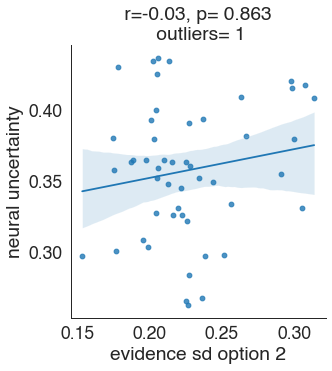

In [123]:
ses = 1#'both'
temp = df_comb_int.xs(ses,0,'session')

y_var ='n2_evidence_sd'
fac = sns.lmplot(data=temp.reset_index() , x =y_var, y = 'sds') #, hue='group',hue='session'
cor = pingouin.corr(temp[y_var], temp['sds'], method='shepherd')
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)
outliers = cor['outliers'][0]
fac.set(xlabel=f'evidence sd option {y_var[1]}',ylabel='neural uncertainty', title = f' r={r_}, p= {p} \n outliers= {outliers}')
plt.savefig(op.join(plot_folder_path, f'sds-{y_var}_ses-{ses}_corr_robust.pdf'), bbox_inches='tight')

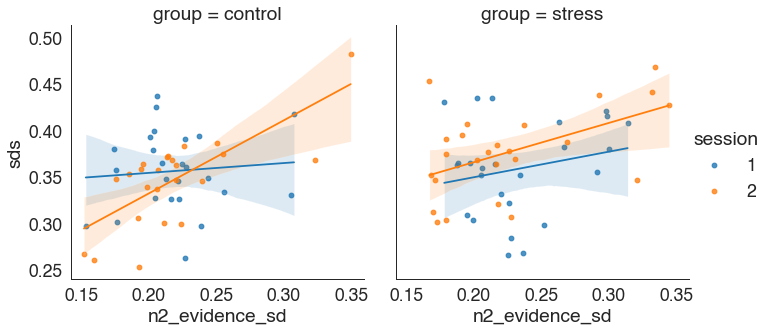

In [92]:
fac = sns.lmplot(data=df_comb_int.reset_index() , x =y_var, y = 'sds',hue='session',col='group') #, hue='group'


### check test-retest reliability 

Text(0.5, 1.0, 'test-retest: n2_evidence_sd')

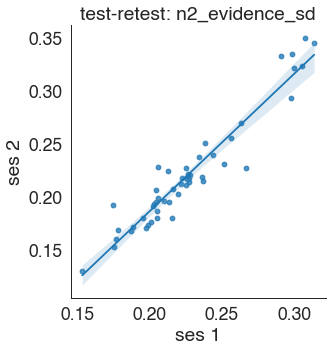

In [122]:
param = 'n2_evidence_sd'
df1 = df_comb_int.xs(1,0,'session')[param].to_frame()
df2 = df_comb_int.xs(2,0,'session')[param].to_frame()

df1 = df1.rename(mapper={param : f'ses 1'},axis=1)
df2 = df2.rename(mapper={param : f'ses 2'},axis=1)

temp = pd.concat([df1,df2],axis=1)
fac = sns.lmplot(data=temp , x ='ses 1', y = 'ses 2') #, hue='group'
plt.title(f'test-retest: {param}')